### [Backtesting a 20-Day Breakout Strategy for 10 Years](https://wire.insiderfinance.io/i-backtested-a-20-day-breakout-strategy-for-10-years-and-the-results-surprised-me-9db7069150ea)

#### **The Strategy: 20-Day Breakout With 10-Day Exit**

- **_Entry rule_**

  Buy when the closing price breaks above the highest high of the past 20 trading days.

- **_Exit rule_**

  Sell when the closing price falls below the lowest low of the past 10 trading days.

In [1]:
!pip install yfinance pandas numpy matplotlib tabulate --quiet

In [2]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules or 'google.colab' in str(get_ipython())

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from tabulate import tabulate

from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.4f}'.format)

import warnings
warnings.filterwarnings('ignore')

In [3]:
ticker = "AAPL"   # Change this to any stock
start_date = "2015-01-01"
end_date = "2024-01-01"

data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)

if data.empty:
  print(f"No data found for {ticker}")
  sys.exit(1)
else:
  if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
  display(data.head(10))
  display(data.info())

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.2149,24.6822,23.7764,24.6711,212818400
2015-01-05,23.5327,24.0643,23.3467,23.9845,257142000
2015-01-06,23.5349,23.7941,23.1739,23.5970,263188400
2015-01-07,23.8649,23.9646,23.6324,23.7431,160423600
2015-01-08,24.7819,24.8395,24.0754,24.1927,237458000
2015-01-09,24.8085,25.0831,24.4098,24.9546,214798000
2015-01-12,24.1972,24.9458,24.0975,24.9391,198603200
2015-01-13,24.4120,24.9834,24.1219,24.6800,268367600
2015-01-14,24.3190,24.4718,24.0311,24.1507,195826400


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2264 entries, 2015-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2264 non-null   float64
 1   High    2264 non-null   float64
 2   Low     2264 non-null   float64
 3   Open    2264 non-null   float64
 4   Volume  2264 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 106.1 KB


None

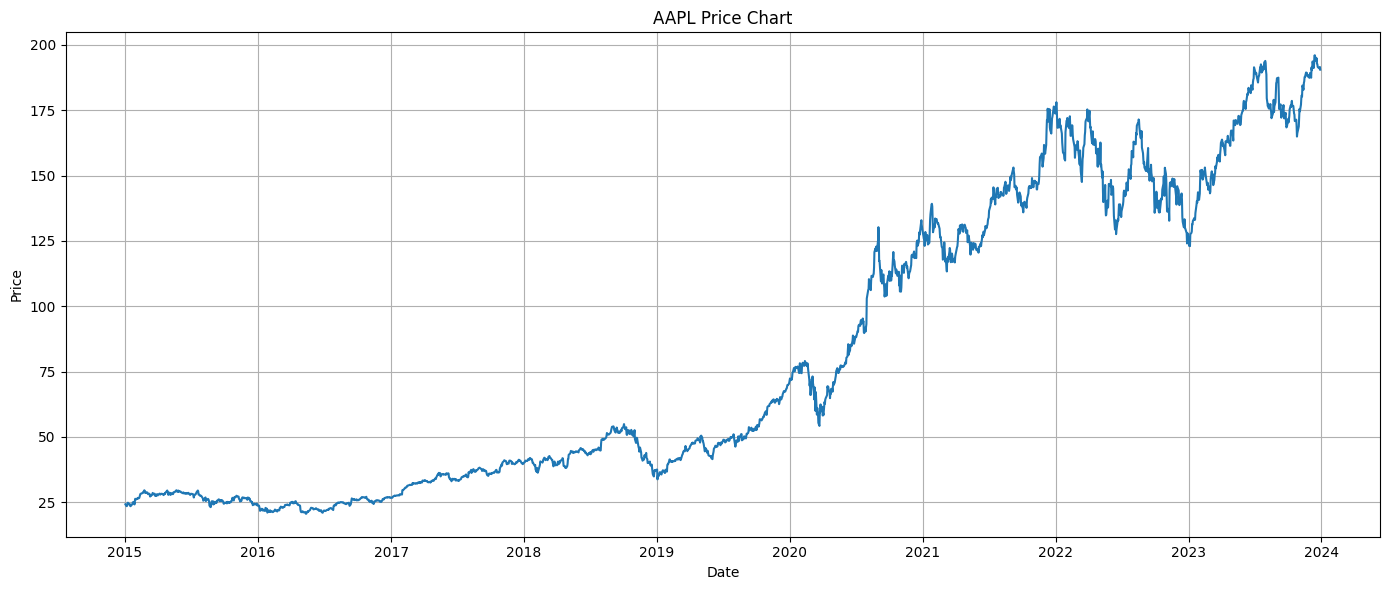

In [4]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'])
plt.title(f"{ticker} Price Chart")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()

if not IN_COLAB:
  plt.savefig("price_chart.png")

plt.show()

In [5]:
lookback_entry = 20
lookback_exit = 10

data['20D_High'] = data['Close'].rolling(lookback_entry).max().shift(1)
data['10D_Low'] = data['Close'].rolling(lookback_exit).min().shift(1)

# Initialize position column
data['Position'] = 0

in_position = False

for i in range(len(data)):
    if not in_position:
        # Entry condition
        if data['Close'].iloc[i] > data['20D_High'].iloc[i]:
            data.at[data.index[i], 'Position'] = 1
            in_position = True

    else:
        # Exit condition
        if data['Close'].iloc[i] < data['10D_Low'].iloc[i]:
            data.at[data.index[i], 'Position'] = 0
            in_position = False
        else:
            data.at[data.index[i], 'Position'] = 1

In [6]:
data['Trade'] = data['Position'].diff()

display(data.head(15))

buy_signals = data[data['Trade'] == 1]
sell_signals = data[data['Trade'] == -1]

print("Number of Buy Signals:", len(buy_signals))
print("Number of Sell Signals:", len(sell_signals))

Price,Close,High,Low,Open,Volume,20D_High,10D_Low,Position,Trade
Date,,,,,,,,,
2015-01-02,24.2149,24.6822,23.7764,24.6711,212818400,NaN,NaN,0,NaN
2015-01-05,23.5327,24.0643,23.3467,23.9845,257142000,NaN,NaN,0,0.0000
2015-01-06,23.5349,23.7941,23.1739,23.5970,263188400,NaN,NaN,0,0.0000
2015-01-07,23.8649,23.9646,23.6324,23.7431,160423600,NaN,NaN,0,0.0000
2015-01-08,24.7819,24.8395,24.0754,24.1927,237458000,NaN,NaN,0,0.0000
2015-01-09,24.8085,25.0831,24.4098,24.9546,214798000,NaN,NaN,0,0.0000
2015-01-12,24.1972,24.9458,24.0975,24.9391,198603200,NaN,NaN,0,0.0000
2015-01-13,24.4120,24.9834,24.1219,24.6800,268367600,NaN,NaN,0,0.0000
2015-01-14,24.3190,24.4718,24.0311,24.1507,195826400,NaN,NaN,0,0.0000


Number of Buy Signals: 49
Number of Sell Signals: 49


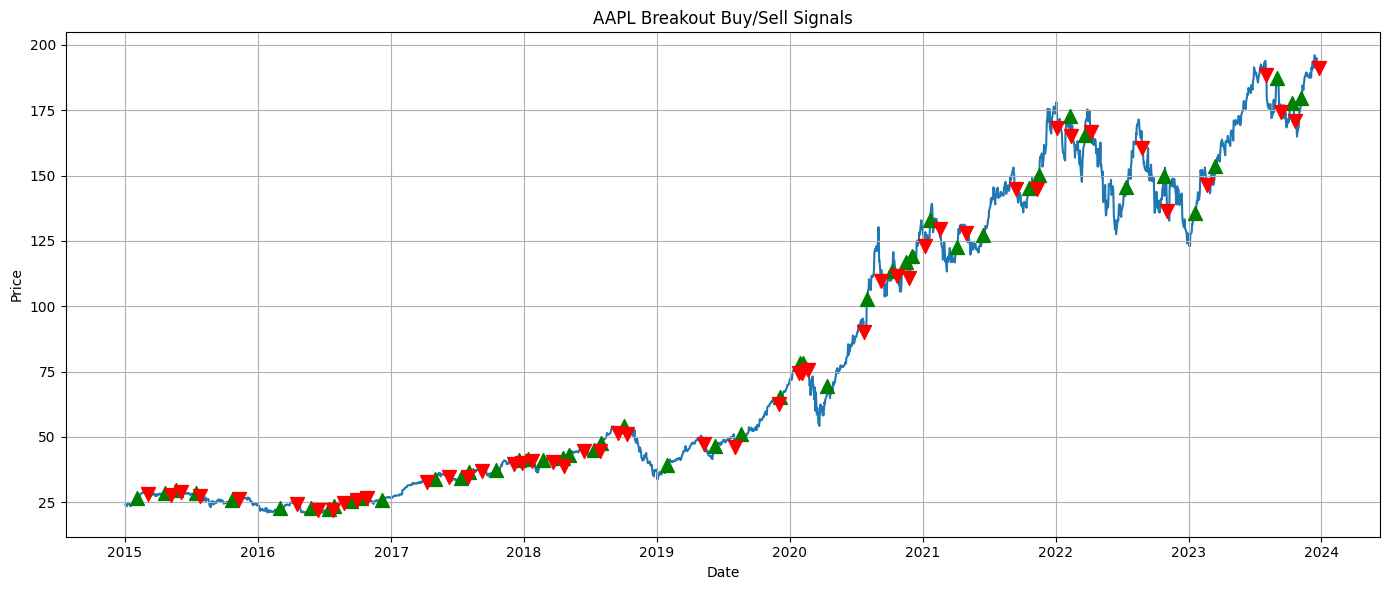

In [7]:
plt.figure(figsize=(14,6))

# Draw the line with a lower z-order
plt.plot(data['Close'], zorder=1)

# Draw buy signals on top
plt.scatter(buy_signals.index,
            buy_signals['Close'],
            marker='^',
            color='green',
            s=100,
            zorder=2)  # higher z-order

# Draw sell signals on top
plt.scatter(sell_signals.index,
            sell_signals['Close'],
            marker='v',
            color='red',
            s=100,
            zorder=2)  # higher z-order

plt.title(f"{ticker} Breakout Buy/Sell Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()

if not IN_COLAB:
  plt.savefig("buy_sell_signals.png")

plt.show()

In [8]:
initial_capital = 10000
cash = initial_capital
shares = 0

equity_curve = []

for i in range(len(data)):
    price = data['Close'].iloc[i]

    # Buy signal
    if data['Trade'].iloc[i] == 1:
        shares = cash // price          # whole shares for breakout strategy
        cash -= shares * price

    # Sell signal
    elif data['Trade'].iloc[i] == -1:
        cash += shares * price
        shares = 0

    total_equity = cash + shares * price
    equity_curve.append(total_equity)

# Store breakout equity curve
data['Strategy_Equity'] = equity_curve


# Buy & Hold

# Allow fractional shares so starting capital is exactly 10,000
shares_bh = initial_capital / data['Close'].iloc[0]
data['Market_Equity'] = shares_bh * data['Close']

display(data.head(15))

Price,Close,High,Low,Open,Volume,20D_High,10D_Low,Position,Trade,Strategy_Equity,Market_Equity
Date,,,,,,,,,,,
2015-01-02,24.2149,24.6822,23.7764,24.6711,212818400,NaN,NaN,0,NaN,10000.0000,10000.0000
2015-01-05,23.5327,24.0643,23.3467,23.9845,257142000,NaN,NaN,0,0.0000,10000.0000,9718.2822
2015-01-06,23.5349,23.7941,23.1739,23.5970,263188400,NaN,NaN,0,0.0000,10000.0000,9719.1991
2015-01-07,23.8649,23.9646,23.6324,23.7431,160423600,NaN,NaN,0,0.0000,10000.0000,9855.4827
2015-01-08,24.7819,24.8395,24.0754,24.1927,237458000,NaN,NaN,0,0.0000,10000.0000,10234.1532
2015-01-09,24.8085,25.0831,24.4098,24.9546,214798000,NaN,NaN,0,0.0000,10000.0000,10245.1295
2015-01-12,24.1972,24.9458,24.0975,24.9391,198603200,NaN,NaN,0,0.0000,10000.0000,9992.6833
2015-01-13,24.4120,24.9834,24.1219,24.6800,268367600,NaN,NaN,0,0.0000,10000.0000,10081.4063
2015-01-14,24.3190,24.4718,24.0311,24.1507,195826400,NaN,NaN,0,0.0000,10000.0000,10042.9890


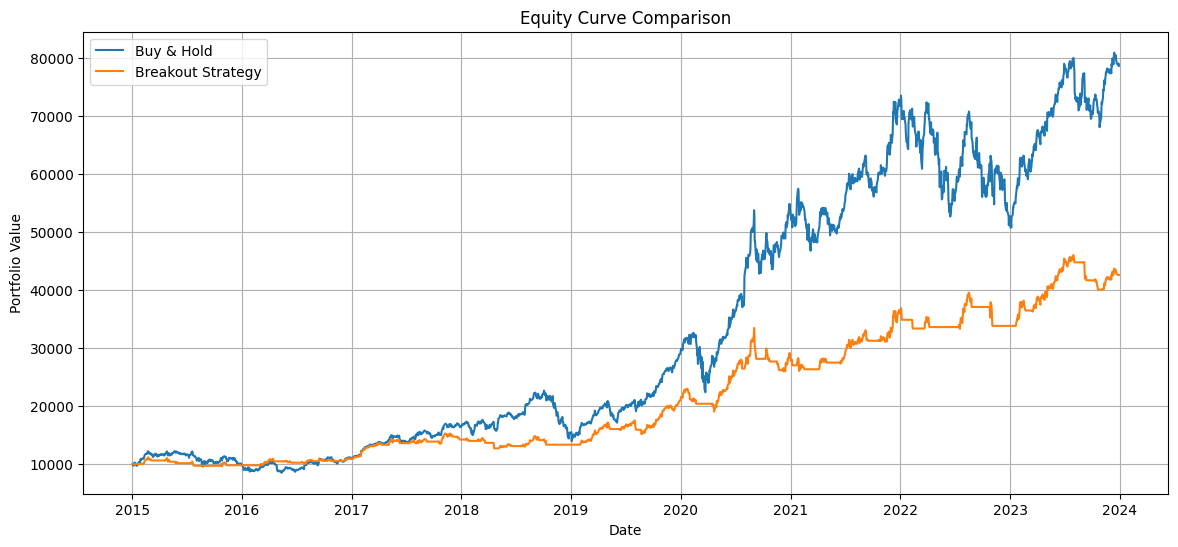

In [9]:
plt.figure(figsize=(14,6))
plt.plot(data['Market_Equity'], label='Buy & Hold')
plt.plot(data['Strategy_Equity'], label='Breakout Strategy')

plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

if not IN_COLAB:
  plt.savefig("equity_comparison.png")

plt.show()

In [10]:
def performance_metrics(equity_curve):

    initial_value = equity_curve.iloc[0]
    final_value = equity_curve.iloc[-1]

    total_return = (final_value / initial_value - 1) * 100
    annual_return = ((final_value / initial_value) ** (252/len(equity_curve)) - 1) * 100

    daily_returns = equity_curve.pct_change().dropna()
    sharpe = np.sqrt(252) * daily_returns.mean() / daily_returns.std()

    drawdown = (equity_curve / equity_curve.cummax() - 1).min() * 100

    return initial_value, final_value, total_return, annual_return, sharpe, drawdown


market_metrics = performance_metrics(data['Market_Equity'])
strategy_metrics = performance_metrics(data['Strategy_Equity'])


results = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Final Value",
        "Total Return (%)",
        "Annual Return (%)",
        "Sharpe Ratio",
        "Max Drawdown (%)"
    ],
    "Buy & Hold": market_metrics,
    "Breakout Strategy": strategy_metrics
})

print(tabulate(results, headers='keys', tablefmt='pretty', showindex=False))

+-------------------+---------------------+---------------------+
|      Metric       |     Buy & Hold      |  Breakout Strategy  |
+-------------------+---------------------+---------------------+
|  Initial Capital  |       10000.0       |       10000.0       |
|    Final Value    |  78691.44978601603  |  42627.32842826843  |
| Total Return (%)  |  686.9144978601604  | 326.27328428268436  |
| Annual Return (%) | 25.812381787243275  | 17.513824269167632  |
|   Sharpe Ratio    | 0.9366644466196171  | 1.0599893988854348  |
| Max Drawdown (%)  | -38.515920670032834 | -22.321076634946046 |
+-------------------+---------------------+---------------------+
